# 04. A shared year effect as a random walk

Notebooks 02 and 03 get the level of each country right and the timing of its events wrong. The country-total coverage fails in both, and the country plots show CHN's hydro counts rising to 2015 and falling after while the model follows the rise and misses the fall. Nothing in the model so far varies by year except the covariates, so any global movement in the record that the covariates do not carry lands in the residual.

This notebook adds one effect per year and class, shared by every country, as a random walk. Each year's effect is the previous year's plus a step with an estimated scale, so a change in the record persists until the next change, and a forecast carries the last level forward with uncertainty that grows with the horizon. The model is meant to forecast, which rules out a free effect per year: one was fit first, as `04a` in the comparison at the end, and it has nothing to say about a year it has not seen. The random walk does not know which country it is in, so a country whose record moves against the global pattern stays wrong. The rest of the model is notebook 03 as it stands.

Sections follow the workflow: the data, the model, what the priors imply, the fit, its diagnostics, what the posterior predicts, the year effects, between against within, the posterior against the prior, the comparison with the earlier notebooks, and what was learned.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from arviz_plots import plot_energy, plot_forest, plot_trace
from checks import (
    INTERVALS,
    count_summaries,
    observed_count_summaries,
    plot_country_counts,
    plot_coverage,
    plot_posterior_with_prior,
    plot_predictive_summaries,
    plot_rootograms,
    summarize,
)

from climate_risk.plotting import PALETTE, configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}

# The paper's covariates with population logged, less the square of GDP per capita.
FEATURES = [("ln_population" if name == "population" else name)
            for name in MODEL_FEATURES if name != "square_ln_gdp_pc"]

# The covariates that get a latent country mean: those that vary between countries.
CONFOUNDED = ["ln_population", "ln_population_density", "ln_gdp_pc"]

## The data

The same panel as notebook 03. The one addition is a year index for the effect.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]),
                 year=lambda frame: frame["date"].dt.year)
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

codes = sorted(panel["iso"].unique())
country_idx = panel["iso"].map({code: position for position, code in enumerate(codes)}).to_numpy()

# nutpie stores the coords, and it rejects numpy integers.
years = sorted(panel["year"].unique().tolist())
year_idx = panel["year"].map({year: position for position, year in enumerate(years)}).to_numpy()

print(f"{len(panel)} country-years, {len(codes)} countries, {years[0]} to {years[-1]}")

7710 country-years, 199 countries, 1981 to 2023


## The model

Notebook 03 with one term added to the log rate. Per class $c$, country $j$, year $t$, and country-year $i$ in country $j$ and year $t$,

$$
\begin{aligned}
\log \mu_{ic} &= a_c + v_{jc} + w_{tc} + \tilde{x}_i^\top \beta^{W}_c + u_j^\top \beta^{B}_c \\
w_{1c} &= 0 \\
w_{tc} &= w_{t-1,c} + \sigma^{Y}_c\, \epsilon_{tc}, \quad \epsilon_{tc} \sim \operatorname{Normal}(0, 1)
\end{aligned}
$$

$w_{tc}$ is the year effect, one number per year and class that every country in that year shares. It starts at zero in 1981, so the intercept $a_c$ is the log rate of an average country in 1981 and the effect is the cumulative movement since. The step scale $\sigma^{Y}_c$ carries a `HalfNormal(0.25)` prior: a typical year moves the log rate by less than a quarter, and 43 such steps can wander a long way. The innovations are sampled as standard normals and the walk is their scaled cumulative sum, which is the non-centered form.

The latents, the measurement model, the two coefficient vectors, and the country intercept are as in notebook 03, with the same priors.

In [4]:
coords = {
    "obs_idx": panel.index,
    "iso": codes,
    "year": years,
    "step": years[1:],
    "disaster": CLASSES,
    "feature": FEATURES,
    "confounded": CONFOUNDED,
    "confounded_": CONFOUNDED,
}
confounded_positions = [FEATURES.index(name) for name in CONFOUNDED]

with pm.Model(coords=coords) as year_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])
    year = pm.Data("year_of", year_idx, dims=["obs_idx"])

    # The covariates are standardized, so the latents carry the whole location: a free grand mean would trade
    # against them.
    latent_chol, latent_corr, latent_scale = pm.LKJCholeskyCov("latent_cov",
                                                              n=len(CONFOUNDED),
                                                              eta=2,
                                                              sd_dist=pm.HalfNormal.dist(1),
                                                              compute_corr=True)
    latent = pm.MvNormal("latent", mu=0, chol=latent_chol, dims=["iso", "confounded"])
    pm.Deterministic("latent_corr", latent_corr, dims=["confounded", "confounded_"])
    pm.Deterministic("latent_scale", latent_scale, dims=["confounded"])

    sigma_X = pm.Exponential("sigma_X", 1, dims=["confounded"])
    pm.Normal("X_hat",
              mu=latent[country],
              sigma=sigma_X,
              observed=X[:, confounded_positions],
              dims=["obs_idx", "confounded"])

    # The confounded columns enter the count as deviations from their latent, the rest as they are.
    X_within = pt.set_subtensor(X[:, confounded_positions], X[:, confounded_positions] - latent[country])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta_within = pm.Normal("beta_within", 0, 0.5, dims=["feature", "disaster"])
    beta_between = pm.Normal("beta_between", 0, 0.5, dims=["confounded", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])

    tau = pm.HalfNormal("tau", 1, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", tau * country_offset, dims=["iso", "disaster"])

    # A random walk from zero in the first year, so the intercept is the first year's level.
    sigma_year = pm.HalfNormal("sigma_year", 0.25, dims=["disaster"])
    year_innovation = pm.Normal("year_innovation", 0, 1, dims=["disaster", "step"])
    year_effect = pm.Deterministic("year_effect",
                                   pt.concatenate([pt.zeros((len(CLASSES), 1)),
                                                   pt.cumsum(sigma_year[:, None] * year_innovation, axis=1)],
                                                  axis=1),
                                   dims=["disaster", "year"])

    log_mu = (intercept
              + country_effect[country]
              + year_effect.T[year]
              + X_within @ beta_within
              + latent[country] @ beta_between)
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims=["obs_idx", "disaster"])

    pm.NegativeBinomial("y",
                        mu=mu,
                        alpha=alpha,
                        observed=counts.to_numpy(),
                        dims=["obs_idx", "disaster"])

year_model

              X = Data(<shared>)
        country = Data(<shared>)
        year_of = Data(<shared>)
     latent_cov ~ _lkjcholeskycov(3, 2, HalfNormal(0, 1))
         latent ~ MultivariateNormal(f(latent_cov), f(latent_cov))
        sigma_X ~ Exponential(<constant>)
      intercept ~ Normal(0, 1)
    beta_within ~ Normal(0, 0.5)
   beta_between ~ Normal(0, 0.5)
          alpha ~ Gamma(2, <constant>)
            tau ~ HalfNormal(0, 1)
 country_offset ~ Normal(0, 1)
     sigma_year ~ HalfNormal(0, 0.25)
year_innovation ~ Normal(0, 1)
latent_cov_corr = Deterministic(f(latent_cov))
latent_cov_stds = Deterministic(f(latent_cov))
    latent_corr = Deterministic(f(latent_cov_corr))
   latent_scale = Deterministic(f(latent_cov_stds))
 country_effect = Deterministic(f(country_offset, tau))
    year_effect = Deterministic(f(year_innovation, sigma_year))
             mu = Deterministic(f(beta_between, country, latent, beta_within, X, year_of, year_effect, country_effect, intercept))
          X_ha

## What the priors imply

The same three summaries as before. A random walk with `HalfNormal(0.25)` steps has a standard deviation of about 1.6 on the log rate by 2023 under the prior, so the prior predictive widens well beyond notebook 03, which is the cost of a walk that can follow a regime change.

Sampling: [X_hat, alpha, beta_between, beta_within, country_offset, intercept, latent, latent_cov, sigma_X, sigma_year, tau, y, year_innovation]


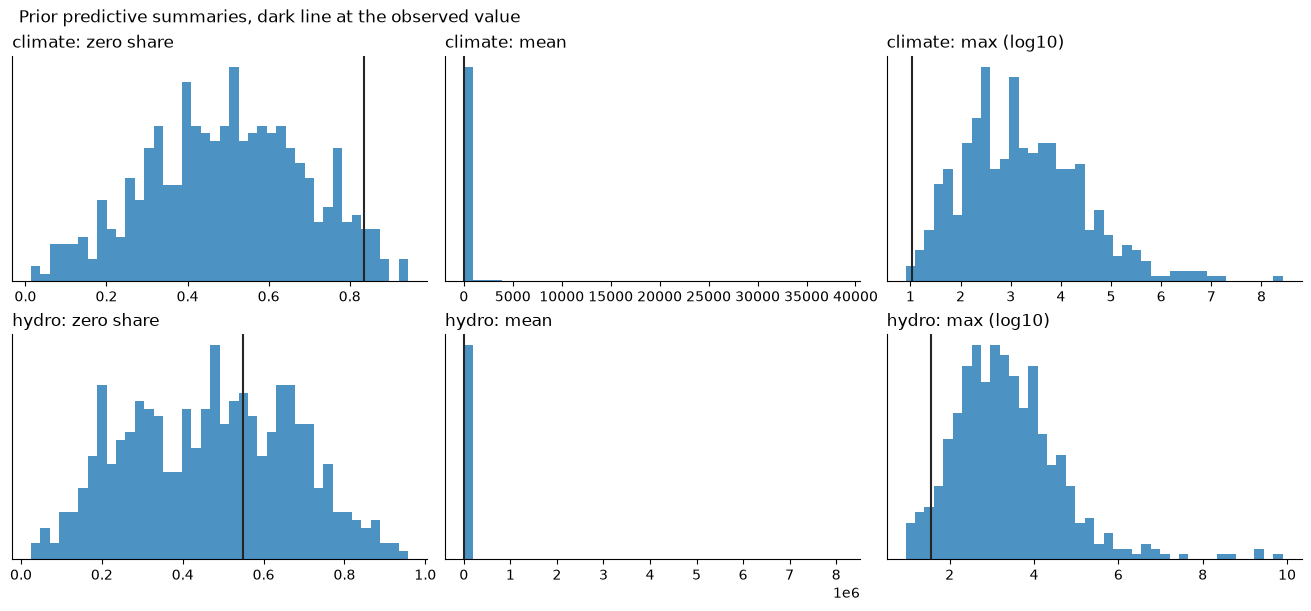

In [5]:
with year_model:
    prior_idata = pm.sample_prior_predictive(draws=500, random_seed=SEED)

observed_summaries = observed_count_summaries(counts)
plot_predictive_summaries(count_summaries(prior_idata.prior_predictive["y"]),
                          observed_summaries,
                          CLASSES,
                          "Prior predictive summaries, dark line at the observed value")

## The fit

The draws land in `fits/`, which is gitignored. `sample_or_load` reads the file back when it exists and does not check that the saved draws came from the data now in memory, so a fit outlives any change to the panel or the feature list. Pass `force_resample=True` after one. The warmup draws are kept this time, to see how adaptation went.

In [6]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     discard_tuned_samples=False,
                     random_seed=SEED)

with year_model:
    idata = sample_or_load(fp=str(FIT_DIR / "year_random_walk.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta_within", "beta_between", "latent_scale", "sigma_X", "alpha", "tau", "sigma_year"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.28,0.50,-3.04,-1.46,154.88,243.09,1.04,0.04,0.03
intercept[hydro],-0.87,0.33,-1.44,-0.36,79.28,73.70,1.09,0.04,0.03
"beta_within[ln_population_density, climate]",-0.74,0.35,-1.30,-0.18,1503.99,1405.00,1.00,0.01,0.01
"beta_within[ln_population_density, hydro]",0.95,0.30,0.47,1.41,607.02,858.95,1.01,0.01,0.01
"beta_within[ln_gdp_pc, climate]",-0.25,0.16,-0.50,0.01,3256.06,1658.36,1.00,0.00,0.00
"beta_within[ln_gdp_pc, hydro]",-0.10,0.07,-0.22,0.02,3406.16,1758.60,1.00,0.00,0.00
"beta_within[precip_deviation, climate]",-0.41,0.04,-0.47,-0.34,3457.00,1930.14,1.00,0.00,0.00
"beta_within[precip_deviation, hydro]",0.24,0.01,0.21,0.26,5352.85,1316.50,1.01,0.00,0.00
"beta_within[co2, climate]",0.69,0.30,0.24,1.18,165.32,233.70,1.04,0.02,0.02
"beta_within[co2, hydro]",0.18,0.20,-0.16,0.48,80.62,71.89,1.08,0.02,0.02


## Diagnostics

The walk is a second hierarchical term with an estimated scale, and the two scales `tau` and `sigma_year` are the parameters most likely to give the sampler trouble. The innovations and the country offsets are summarized alongside the named parameters. The 1981 level is fixed at zero, so it is left out.

2 divergences; worst r_hat 1.095; smallest bulk ESS 68 (country_offset[CHN, hydro])


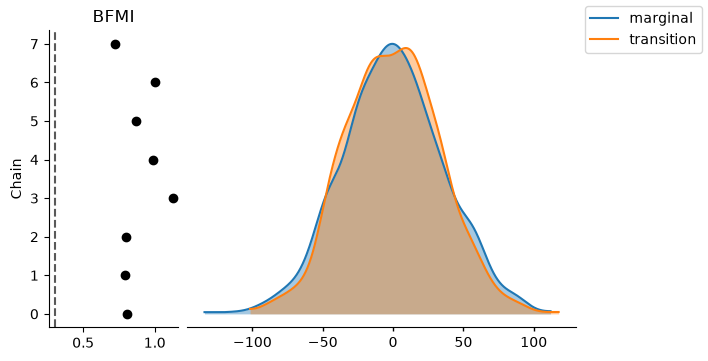

In [7]:
diagnostics = summarize(idata, [*PARAMETERS, "latent", "country_offset", "year_innovation"])[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

### Adaptation

The warmup traces of the two scales, one line per chain. Chains that agree by the end of warmup and then hold still are what a settled adaptation looks like. A chain still drifting at draw 500 says the tuning was too short, and a chain parked at a different level from the rest says the posterior has more than one basin.

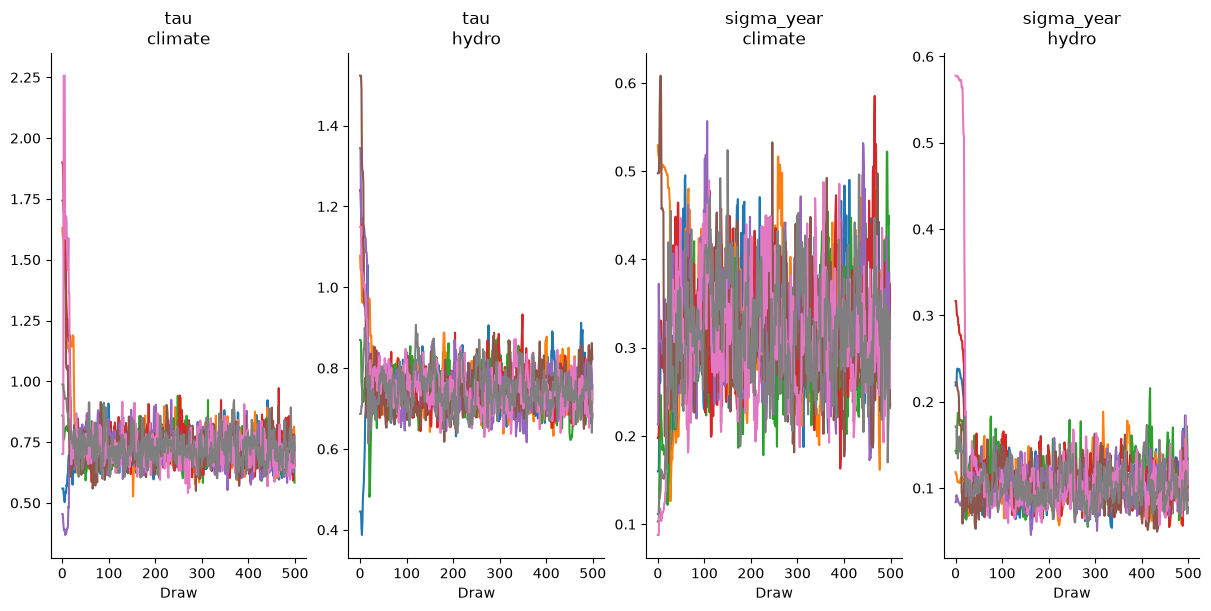

In [8]:
warmup = xr.DataTree.from_dict({"posterior": idata.warmup_posterior.to_dataset()[["tau", "sigma_year"]]})
plot_trace(warmup,
           backend="matplotlib",
           figure_kwargs={"figsize": (12, 6)})
plt.show()

## What the posterior predicts

The same three checks as before.

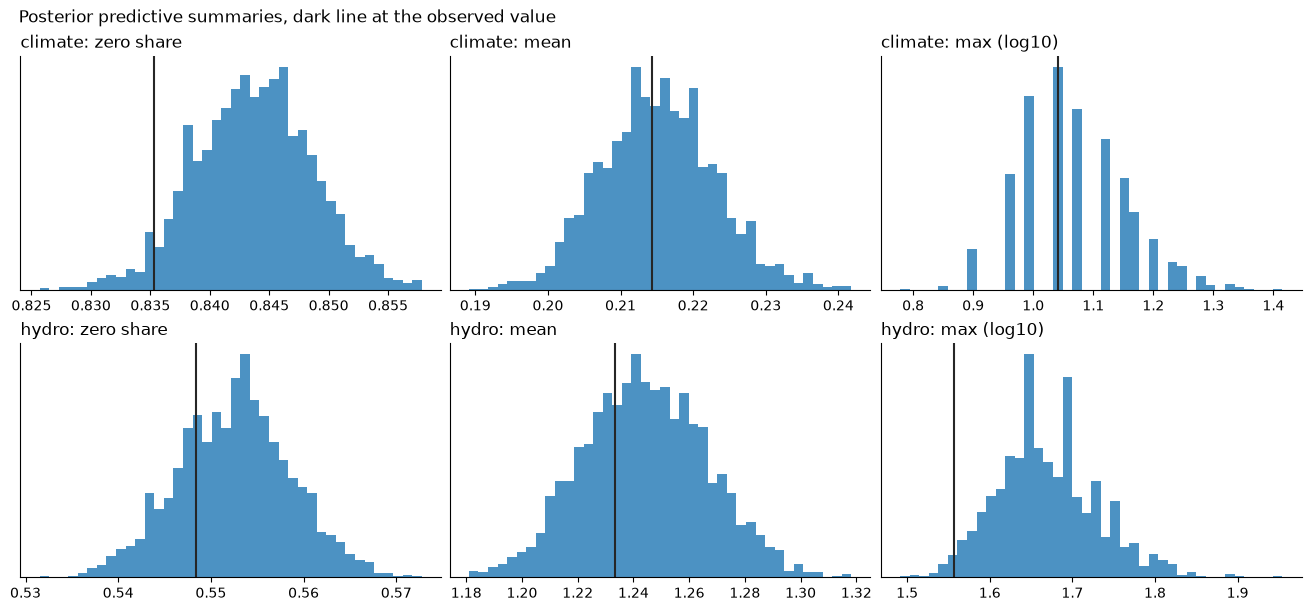

In [9]:
posterior_y = idata.posterior_predictive["y"]
plot_predictive_summaries(count_summaries(posterior_y),
                          observed_summaries,
                          CLASSES,
                          "Posterior predictive summaries, dark line at the observed value")

### The count distribution

Predicted frequency per count with its interval, observed as points, on a square-root axis.

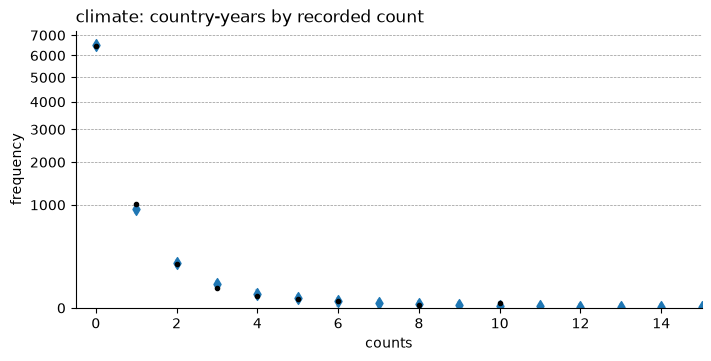

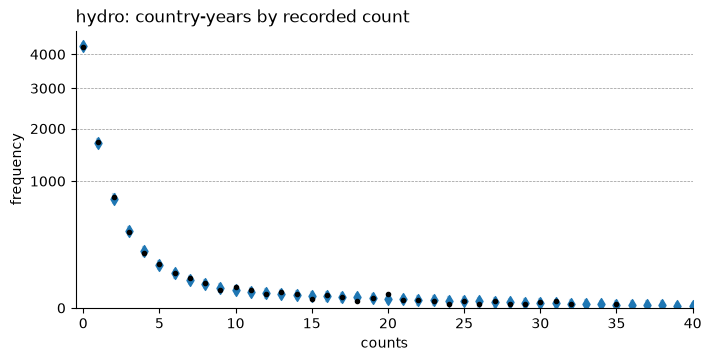

In [10]:
plot_rootograms(idata, counts, CLASSES)

### Interval coverage

Actual coverage minus nominal at every interval width, per country-year on the top row and per country total on the bottom, with the 99% simultaneous envelope. The country totals are the check that failed in notebooks 01 to 03, and a shared year effect can only help them if the countries' timing errors line up.

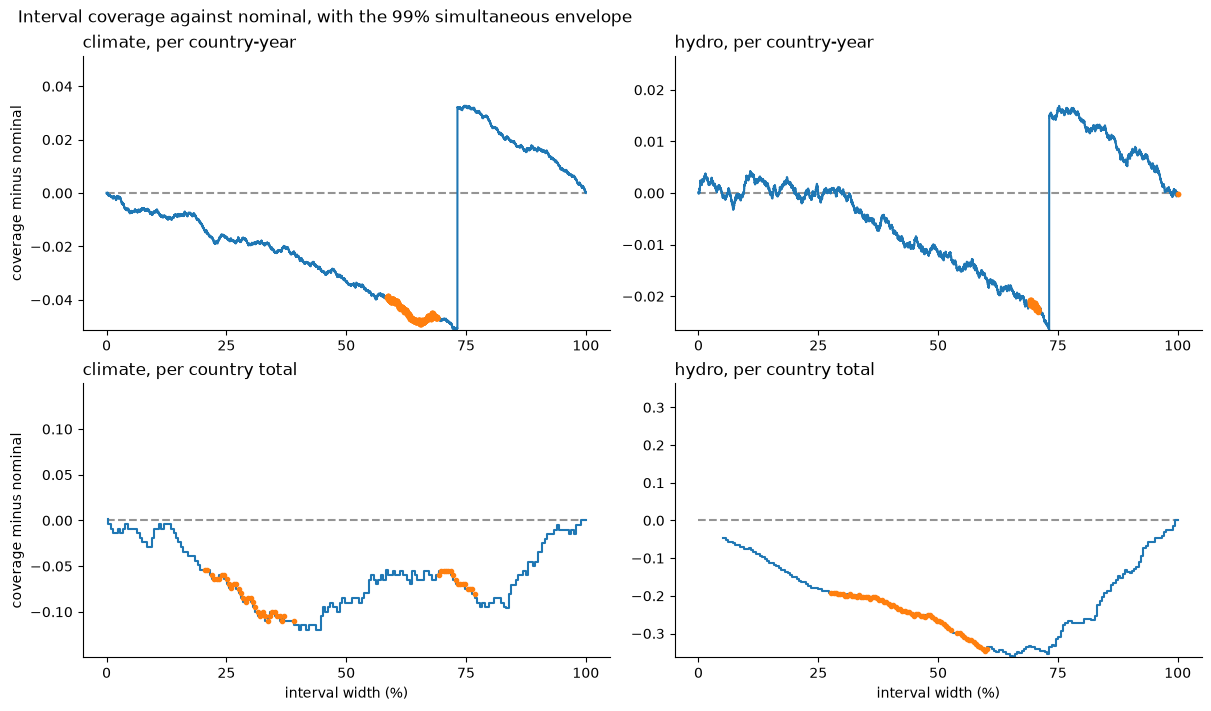

In [11]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

## The year effects

The posterior of $w_{tc}$ over years, one panel per class, with stacked central intervals. The walk starts at zero in 1981 by construction. A level shift that holds is a change in the record the covariates did not carry, and the band widening toward 2023 is the walk's level trading against the within-country `co2` slope, since emissions grow in nearly every country at once and the walk can carry the same movement.

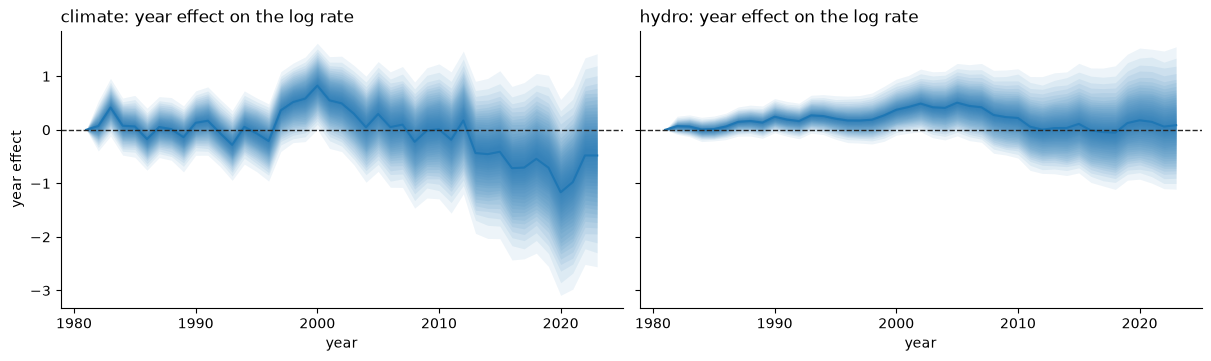

In [12]:
year_draws = idata.posterior["year_effect"].stack(sample=("chain", "draw"))

fig, axes = plt.subplots(1, len(CLASSES), figsize=(12, 3.5), sharey=True)

for axis, name in zip(axes, CLASSES, strict=True):
    draws = year_draws.sel(disaster=name)

    for prob in INTERVALS[::-1]:
        low, high = draws.quantile([(1 - prob) / 2, (1 + prob) / 2], dim="sample").to_numpy()
        axis.fill_between(years, low, high, color=PALETTE["primary"], alpha=0.08, linewidth=0)

    axis.plot(years, draws.mean(dim="sample"), color=PALETTE["primary"])
    axis.axhline(0, color=PALETTE["observed"], linewidth=1, linestyle="--")
    axis.set_title(f"{name}: year effect on the log rate", loc="left")
    axis.set_xlabel("year")

axes[0].set_ylabel("year effect")
plt.show()

## Between against within

The slopes as in notebook 03. The one to watch is `co2`, which trends within every country and so competes with the year effect for the same movement.

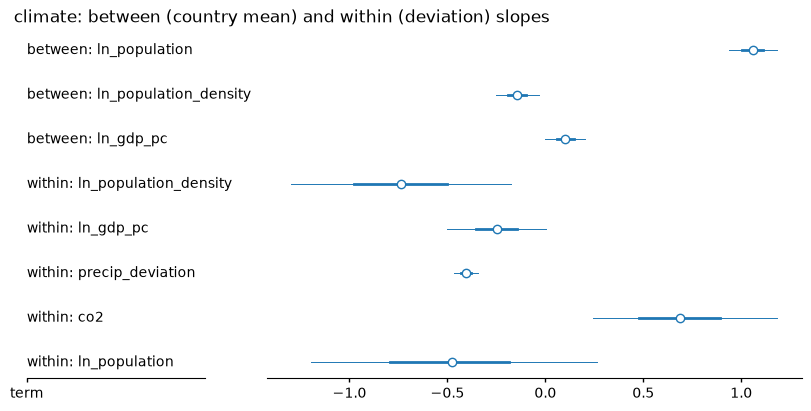

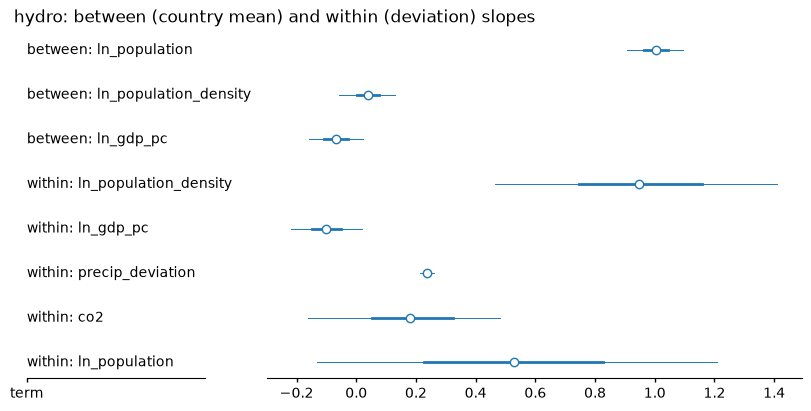

In [13]:
between = idata.posterior["beta_between"].rename(confounded="term")
between = between.assign_coords(term=[f"between: {name}" for name in between["term"].to_numpy()])
within = idata.posterior["beta_within"].rename(feature="term")
within = within.assign_coords(term=[f"within: {name}" for name in within["term"].to_numpy()])
slopes = xr.concat([between, within], dim="term").to_dataset(name="slope")

for name in CLASSES:
    grid = plot_forest(slopes,
                       coords={"disaster": name},
                       combined=True,
                       labels=["term"],
                       backend="matplotlib",
                       figure_kwargs={"figsize": (8, 4)})
    grid.viz["figure"].item().suptitle(f"{name}: between (country mean) and within (deviation) slopes",
                                       x=0.01,
                                       ha="left")
plt.show()

## A few countries over time

The same three countries, for comparison with notebooks 02 and 03.

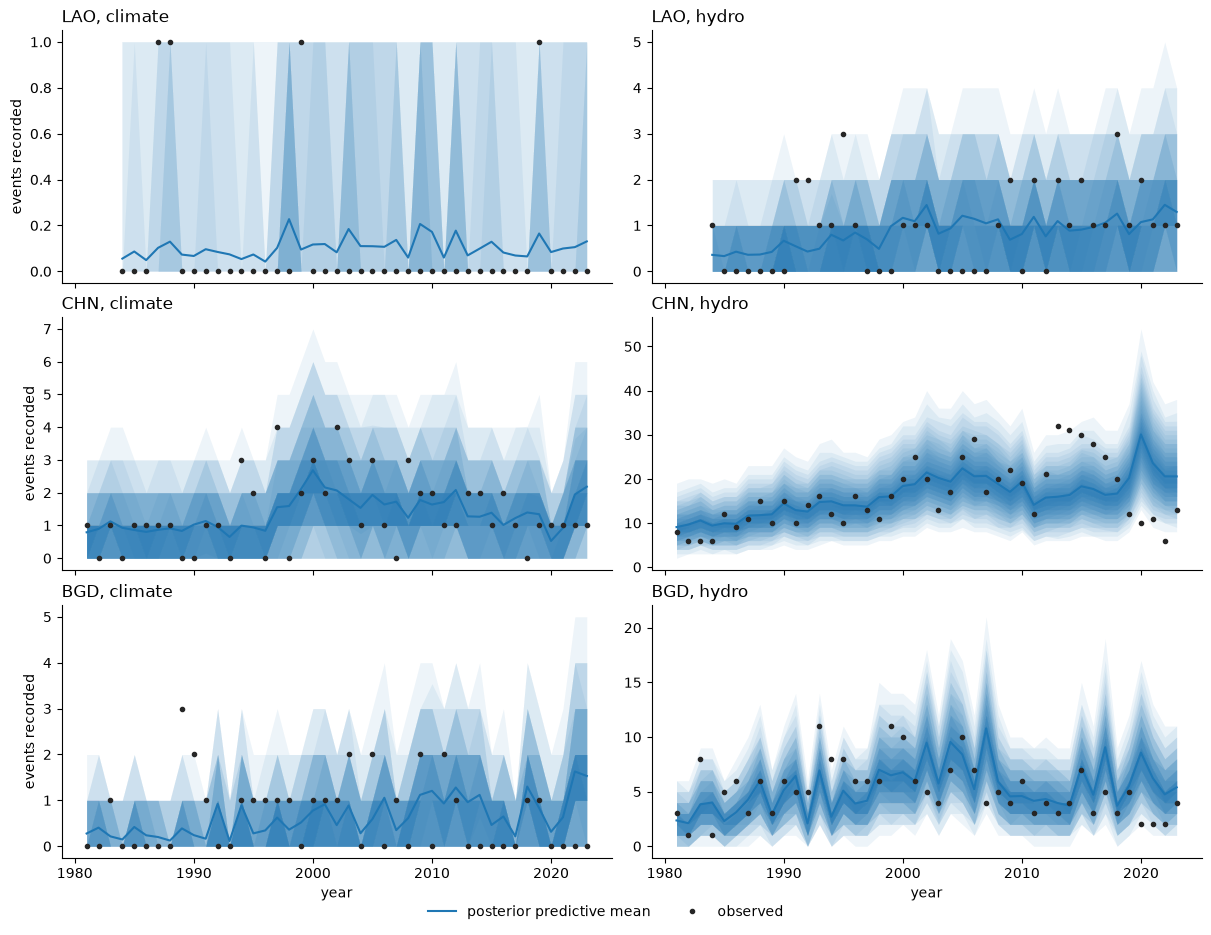

In [14]:
plot_country_counts(posterior_y, panel, counts, ["LAO", "CHN", "BGD"], CLASSES)

## The posterior against the prior

Each panel is the posterior of one parameter in blue over its prior in orange.

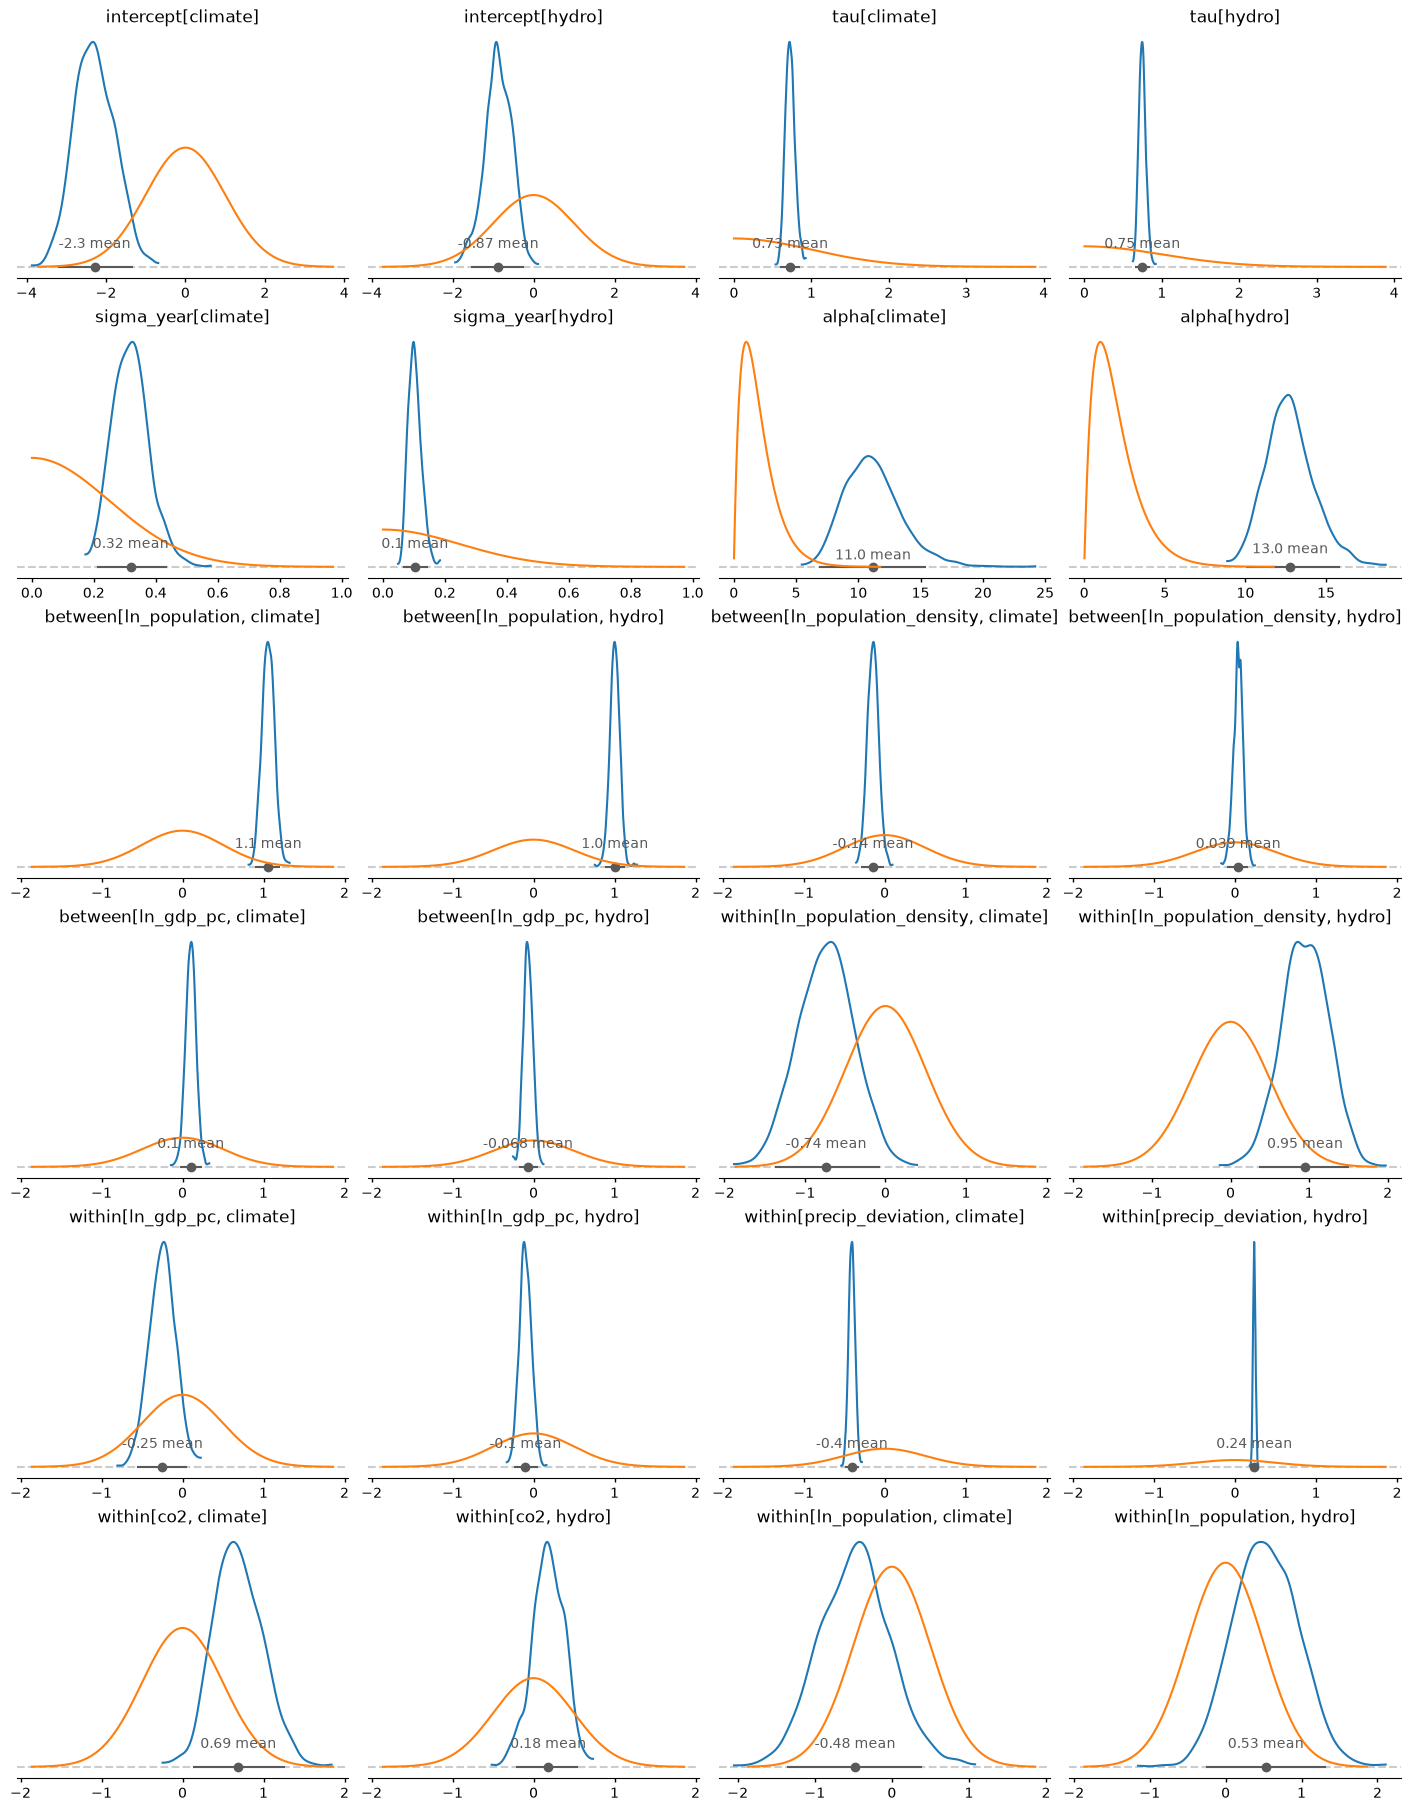

In [15]:
posterior = idata.posterior
of_interest = xr.Dataset({
    **{f"intercept[{name}]": posterior["intercept"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"tau[{name}]": posterior["tau"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"sigma_year[{name}]": posterior["sigma_year"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"between[{feature}, {name}]": posterior["beta_between"].sel(confounded=feature, disaster=name, drop=True)
       for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": posterior["beta_within"].sel(feature=feature, disaster=name, drop=True)
       for feature in FEATURES for name in CLASSES},
})

priors = {
    **{f"intercept[{name}]": pz.Normal(0, 1) for name in CLASSES},
    **{f"tau[{name}]": pz.HalfNormal(1) for name in CLASSES},
    **{f"sigma_year[{name}]": pz.HalfNormal(0.25) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
    **{f"between[{feature}, {name}]": pz.Normal(0, 0.5) for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": pz.Normal(0, 0.5) for feature in FEATURES for name in CLASSES},
}

plot_posterior_with_prior(of_interest, priors)
plt.show()

## Against the earlier notebooks

Leave-one-out expected log predictive density for the count, on the fits so far, with the free-effect version of this notebook as `04a`. Only the `y` log likelihood enters. Leaving out a country-year favors any model with a country intercept, and it favors a year effect the same way: the other 198 countries in that year say most of what the year effect is.

In [16]:
EARLIER_FITS = {"01 zinb glm": "zinb_glm.nc",
                "02 country intercept": "country_intercept.nc",
                "03 latent country means": "latent_confound.nc",
                "04a iid year effect": "year_effect.nc"}

fits = {name: az.from_netcdf(FIT_DIR / path) for name, path in EARLIER_FITS.items()}
fits["04 year random walk"] = idata

comparison = az.compare({name: az.loo(fit, var_name="y") for name, fit in fits.items()}, round_to=1)
comparison[["rank", "elpd", "se", "elpd_diff", "dse", "p"]]

,rank,elpd,se,elpd_diff,dse,p
04 year random walk,0,-11484.20,115.60,0.00,0.00,320.90
04a iid year effect,1,-11484.40,115.60,-0.20,5.00,336.00
03 latent country means,2,-11651.20,117.10,-167.00,17.40,284.60
02 country intercept,3,-11664.60,117.10,-180.40,18.00,284.80
01 zinb glm,4,-12912.90,129.70,-1428.70,49.90,16.80


## What was learned

There is a shared year signal, and it is larger for climate than hydro. The climate walk steps by 0.32 a year and the hydro walk by 0.10. Climate sits near zero through 1996, jumps to +0.8 in 1997, holds above zero for a decade, and drifts down to about -1 by 2020 with a wide band. Hydro climbs to +0.4 over 2000 to 2008 and settles back to zero after 2015. The free-effect fit `04a` found the same shapes year by year, and the two fits are 0.2 apart in LOO with a standard error of 5, so the walk loses nothing in fit and gains a forecast. The climate step in 1997 has the shape a change in how the record is kept would leave, and it is worth checking against EM-DAT's own account of its collection history before reading it as climate.

The walk and the within-country `co2` slope trade. Emissions rise in nearly every country over the period, so the sum of a common trend in `co2` and a drifting walk is pinned while the split between them is not. The `co2` slope for climate is 0.69 with a standard deviation of 0.30, against 0.29 with 0.05 in notebook 03, and its ESS fell to 165. The intercept, which is the 1981 level, has a standard deviation of 0.50 for the same reason. The band on the walk widens toward 2023 as the posterior spreads over those splits. The other slopes match notebook 03, and the dispersions rose to 11.2 and 12.8 as the walk took part of what the negative binomial was covering.

The country-total coverage did not move. Hydro totals still fall 30 points short of nominal at the 50% interval and climate totals 10 points, the same as notebook 03. A year effect that every country shares can only repair errors every country shares, and the country plots say those are the minority: CHN's hydro counts fall after 2015 while the model, following population and CO2, still rises. The remaining timing error is country-specific, which points at a country-level random walk next, and the `co2` trade says the shared trend should be pinned to one of the two before that is added.